# Run pipeline and print initial accuracies
Run all cells to refresh the pipeline data, select and retrain the winning model, and print each candidate's initial 2019 validation accuracy, both overall and on seats whose winning party changed from the previous election. Then evaluate the selected model on the held-out test data and plot its confusion matrix.

In [10]:
from pathlib import Path
import importlib
import sys

# Find this checkout from either the project or notebook directory.
working_directory = Path.cwd().resolve()
project_root = next(
    (folder for folder in (working_directory, *working_directory.parents)
     if (folder / "Run Pipeline" / "run_pipeline.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Open this notebook from inside the election project.")

pipeline_directory = project_root / "Run Pipeline"
# Prefer this checkout and import fresh pipeline code on every run.
for folder in (project_root, pipeline_directory, pipeline_directory / "additional_funcs"):
    folder_string = str(folder)
    if folder_string in sys.path:
        sys.path.remove(folder_string)
    sys.path.insert(0, folder_string)

importlib.invalidate_caches()
for module_name in ("run_pipeline", "automated_model_selection"):
    sys.modules.pop(module_name, None)

from run_pipeline import run_pipeline
print(f"Running pipeline from: {pipeline_directory / 'run_pipeline.py'}")


Running pipeline from: /workspaces/Election-Prediction-12.08/Run Pipeline/run_pipeline.py


In [11]:
final_model, model_type = run_pipeline()
initial_accuracies = final_model.initial_accuracies

print("\nInitial model accuracies (complete 2019 rows, before retraining):")
for name, accuracy in initial_accuracies.items():
    print(f"{name}: {accuracy:.2%}")
print(f"\n2019 accuracy on seats whose winning party changed ({final_model.changed_seat_evaluation_rows} complete rows, before retraining):")
for name, accuracy in final_model.initial_changed_seat_accuracies.items():
    score = f"{accuracy:.2%}" if accuracy is not None else "N/A (no eligible seats)"
    print(f"{name}: {score}")
print(f"Selected model: {model_type}")


/workspaces/Election-Prediction-12.08/.venv/lib/python3.14/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


Initial model accuracies on 629 complete 2019 rows:
  XGBoost: 87.76%; changed winning party: 4.00% (75 seats); combined score: 0.9176
  Random Forest: 86.80%; changed winning party: 4.00% (75 seats); combined score: 0.9080
  Logistic Regression: 85.53%; changed winning party: 12.00% (75 seats); combined score: 0.9753
  Neural Network: 88.24%; changed winning party: 25.33% (75 seats); combined score: 1.1357
Selected Neural Network; retraining using its model-specific procedure.

Initial model accuracies (complete 2019 rows, before retraining):
XGBoost: 87.76%
Random Forest: 86.80%
Logistic Regression: 85.53%
Neural Network: 88.24%

2019 accuracy on seats whose winning party changed (75 complete rows, before retraining):
XGBoost: 4.00%
Random Forest: 4.00%
Logistic Regression: 12.00%
Neural Network: 25.33%
Selected model: Neural Network


## Held-out test evaluation
Evaluate the retrained model on complete test rows, using the same completeness requirement as the 2019 validation. Confusion matrix rows show actual winning parties; columns show predicted winning parties.

Test accuracy (Neural Network): 72.14%
Evaluated 621 of 632 test seats; excluded 11 rows with missing predictors or winners.


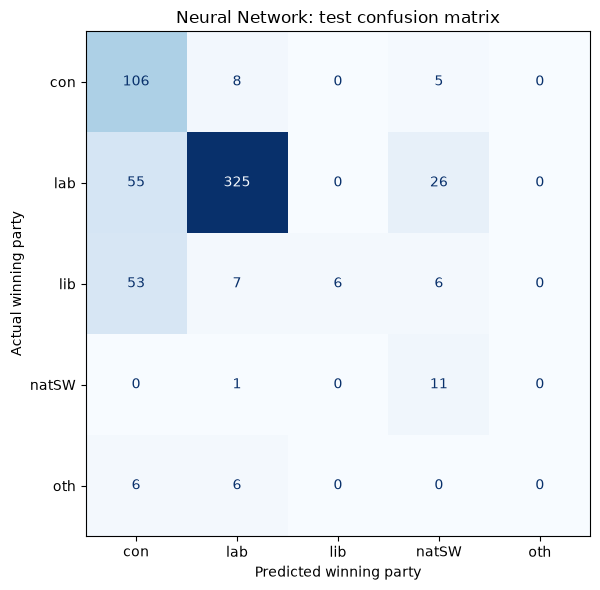

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from Models.logistic_regression import FEATURE_COLUMNS

test_data = pd.read_csv(project_root / "TEST_TRAIN" / "test.csv")
test_evaluation = test_data.dropna(subset=FEATURE_COLUMNS + ["winner"])
if test_evaluation.empty:
    raise ValueError("Test data has no complete rows with known winners to evaluate.")

test_predictions = final_model.predict(test_evaluation)
test_accuracy = accuracy_score(test_evaluation["winner"], test_predictions)
print(f"Test accuracy ({model_type}): {test_accuracy:.2%}")
print(f"Evaluated {len(test_evaluation)} of {len(test_data)} test seats; "
      f"excluded {len(test_data) - len(test_evaluation)} rows with missing predictors or winners.")

party_labels = sorted(set(test_evaluation["winner"]) | set(test_predictions))
test_confusion_matrix = confusion_matrix(
    test_evaluation["winner"], test_predictions, labels=party_labels
)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(test_confusion_matrix, display_labels=party_labels).plot(
    ax=ax, cmap="Blues", values_format="d", colorbar=False
)
ax.set_title(f"{model_type}: test confusion matrix")
ax.set_xlabel("Predicted winning party")
ax.set_ylabel("Actual winning party")
fig.tight_layout()
plt.show()
